In [29]:
import pandas as pd 

In [30]:
df = pd.read_csv("Documents/PostAllstarBreak.csv")

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   game_id              137 non-null    int64  
 1   date                 137 non-null    object 
 2   away_team            137 non-null    object 
 3   home_team            137 non-null    object 
 4   away_score           137 non-null    int64  
 5   home_score           137 non-null    int64  
 6   game_status          137 non-null    object 
 7   location             0 non-null      float64
 8   referees             137 non-null    object 
 9   opening_spread       137 non-null    float64
 10  opening_total        137 non-null    float64
 11  draftkings_lines     0 non-null      float64
 12  scraped_at           137 non-null    object 
 13  start_time_utc       137 non-null    object 
 14  scraped_at_utc       137 non-null    object 
 15  status               137 non-null    obj

In [32]:
df = df.dropna(axis=1, how="all")

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   game_id              137 non-null    int64  
 1   date                 137 non-null    object 
 2   away_team            137 non-null    object 
 3   home_team            137 non-null    object 
 4   away_score           137 non-null    int64  
 5   home_score           137 non-null    int64  
 6   game_status          137 non-null    object 
 7   referees             137 non-null    object 
 8   opening_spread       137 non-null    float64
 9   opening_total        137 non-null    float64
 10  scraped_at           137 non-null    object 
 11  start_time_utc       137 non-null    object 
 12  scraped_at_utc       137 non-null    object 
 13  status               137 non-null    object 
 14  winner               137 non-null    object 
 15  loser                137 non-null    obj

In [34]:
home_df = pd.DataFrame({
    "game_id": df["game_id"],
    "date": df["date"],
    "team": df["home_team"],
    "opponent": df["away_team"],
    "points_scored": df["home_score"],
    "points_allowed": df["away_score"],
    "is_home": 1,
    "win": (df["home_score"] > df["away_score"]).astype(int)
})

away_df = pd.DataFrame({
    "game_id": df["game_id"],
    "date": df["date"],
    "team": df["away_team"],
    "opponent": df["home_team"],
    "points_scored": df["away_score"],
    "points_allowed": df["home_score"],
    "is_home": 0,
    "win": (df["away_score"] > df["home_score"]).astype(int)
})

team_games = pd.concat([home_df, away_df], ignore_index=True)

In [35]:
team_summary = team_games.groupby("team").agg(
    games=("game_id", "count"),
    wins=("win", "sum"),
    avg_points_scored=("points_scored", "mean"),
    avg_points_allowed=("points_allowed", "mean")
)

team_summary["win_pct"] = team_summary["wins"] / team_summary["games"]
print(team_summary.sort_values("win_pct", ascending=False))

                        games  wins  avg_points_scored  avg_points_allowed  \
team                                                                         
San Antonio Spurs          10     9         121.200000          107.900000   
Oklahoma City Thunder       9     8         112.000000          104.777778   
Atlanta Hawks               8     7         120.625000          107.875000   
Boston Celtics             10     8         110.100000           98.900000   
Miami Heat                  9     7         123.555556          112.444444   
Minnesota Timberwolves      8     6         111.125000          112.375000   
Orlando Magic              10     7         115.200000          105.000000   
Los Angeles Lakers         10     6         115.100000          109.600000   
Charlotte Hornets          10     6         117.000000          105.400000   
Houston Rockets            10     6         114.400000          111.100000   
New York Knicks            10     6         110.900000          

In [36]:
print(df["ats_winner"].value_counts(dropna=False))

Charlotte Hornets         8
Boston Celtics            8
New Orleans Pelicans      7
Atlanta Hawks             7
Orlando Magic             7
LA Clippers               7
Miami Heat                7
San Antonio Spurs         6
Memphis Grizzlies         6
Los Angeles Lakers        5
New York Knicks           5
Dallas Mavericks          5
Houston Rockets           5
Chicago Bulls             4
Golden State Warriors     4
Oklahoma City Thunder     4
Denver Nuggets            4
Cleveland Cavaliers       4
Milwaukee Bucks           4
Toronto Raptors           4
Washington Wizards        4
Sacramento Kings          3
Philadelphia 76ers        3
Portland Trail Blazers    3
Phoenix Suns              3
Detroit Pistons           3
Utah Jazz                 3
Brooklyn Nets             2
Minnesota Timberwolves    2
Name: ats_winner, dtype: int64


In [37]:
print(df["ou_result"].value_counts(dropna=False))

under    73
over     64
Name: ou_result, dtype: int64


In [38]:
df["total_diff_vs_line"] = df["total_points"] - df["opening_total"]



In [39]:
(df[["total_points", "opening_total", "total_diff_vs_line"]].head())

,total_points,opening_total,total_diff_vs_line
0,206,218.5,-12.5
1,196,229.5,-33.5
2,224,241.5,-17.5
3,217,233.5,-16.5
4,237,218.5,18.5


In [40]:
(df["total_diff_vs_line"].describe())

count    137.000000
mean      -2.390511
std       17.840255
min      -55.500000
25%      -15.500000
50%       -1.500000
75%       10.500000
max       50.500000
Name: total_diff_vs_line, dtype: float64

In [43]:
spreads_diff = (df.sort_values("total_diff_vs_line", ascending=False)[
    ["date", "away_team", "home_team", "total_points", "opening_total", "total_diff_vs_line"]
])

In [44]:
spreads_diff

,date,away_team,home_team,total_points,opening_total,total_diff_vs_line
67,2026-02-27 19:30:00-05,Brooklyn Nets,Boston Celtics,259,208.5,50.5
135,2026-03-08 20:00:00-04,Houston Rockets,San Antonio Spurs,265,223.5,41.5
15,2026-02-20 20:00:00-05,Milwaukee Bucks,New Orleans Pelicans,257,224.5,32.5
85,2026-03-01 21:00:00-05,New Orleans Pelicans,LA Clippers,254,222.5,31.5
23,2026-02-21 20:00:00-05,Sacramento Kings,San Antonio Spurs,261,230.5,30.5
...,...,...,...,...,...,...
1,2026-02-19 19:00:00-05,Brooklyn Nets,Cleveland Cavaliers,196,229.5,-33.5
65,2026-02-26 22:00:00-05,Minnesota Timberwolves,LA Clippers,182,220.5,-38.5
55,2026-02-25 22:00:00-05,Boston Celtics,Denver Nuggets,187,228.5,-41.5
84,2026-03-01 20:00:00-05,Oklahoma City Thunder,Dallas Mavericks,187,236.5,-49.5


In [48]:
team_total_summary = team_totals.groupby("team").agg(
    games=("game_id", "count"),
    avg_total_diff=("total_diff_vs_line", "mean"),
    avg_abs_total_diff=("abs_total_diff_vs_line", "mean"),
    max_abs_total_diff=("abs_total_diff_vs_line", "max")
).sort_values("avg_abs_total_diff", ascending=False)

print(team_total_summary)

                        games  avg_total_diff  avg_abs_total_diff  \
team                                                                
Boston Celtics             10       -9.800000           23.800000   
New York Knicks            10      -10.400000           18.300000   
Oklahoma City Thunder       9       -8.166667           18.166667   
Brooklyn Nets              10       -0.500000           17.300000   
San Antonio Spurs          10        1.300000           16.900000   
Portland Trail Blazers      8       -8.250000           16.750000   
New Orleans Pelicans       10        4.000000           16.700000   
Dallas Mavericks           10       -6.400000           16.700000   
Phoenix Suns                9      -13.611111           15.833333   
Denver Nuggets              9        1.388889           15.722222   
Washington Wizards         10        4.300000           15.700000   
Cleveland Cavaliers         9       -7.500000           15.055556   
Milwaukee Bucks            10     

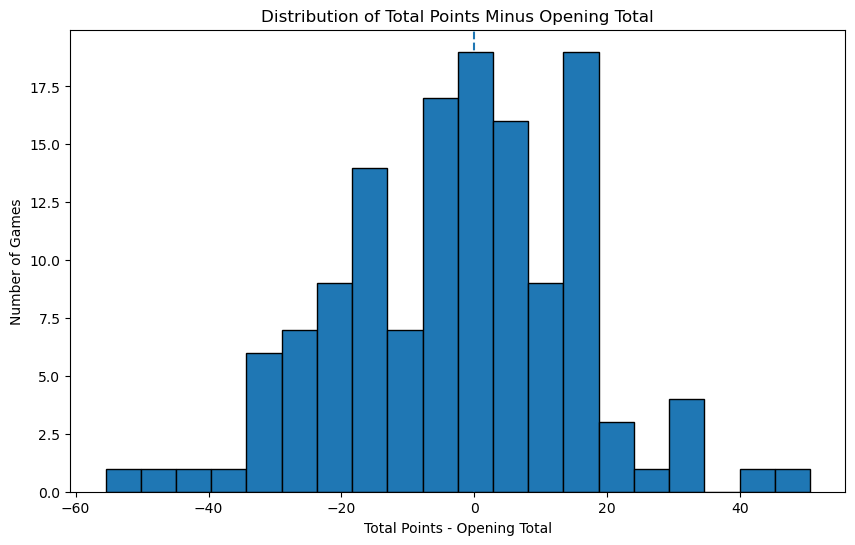

In [45]:
import matplotlib.pyplot as plt

# make sure the column exists
df = df.copy()
df["total_diff_vs_line"] = df["total_points"] - df["opening_total"]

plt.figure(figsize=(10, 6))
plt.hist(df["total_diff_vs_line"], bins=20, edgecolor="black")
plt.axvline(0, linestyle="--")
plt.title("Distribution of Total Points Minus Opening Total")
plt.xlabel("Total Points - Opening Total")
plt.ylabel("Number of Games")
plt.show()

In [46]:
df = df.copy()
df["total_diff_vs_line"] = df["total_points"] - df["opening_total"]
df["abs_total_diff_vs_line"] = df["total_diff_vs_line"].abs()

In [47]:
import pandas as pd

home_team_totals = df[[
    "game_id", "date", "home_team", "away_team",
    "total_points", "opening_total", "total_diff_vs_line", "abs_total_diff_vs_line"
]].copy()

home_team_totals = home_team_totals.rename(columns={
    "home_team": "team",
    "away_team": "opponent"
})
home_team_totals["is_home"] = 1

away_team_totals = df[[
    "game_id", "date", "away_team", "home_team",
    "total_points", "opening_total", "total_diff_vs_line", "abs_total_diff_vs_line"
]].copy()

away_team_totals = away_team_totals.rename(columns={
    "away_team": "team",
    "home_team": "opponent"
})
away_team_totals["is_home"] = 0

team_totals = pd.concat([home_team_totals, away_team_totals], ignore_index=True)

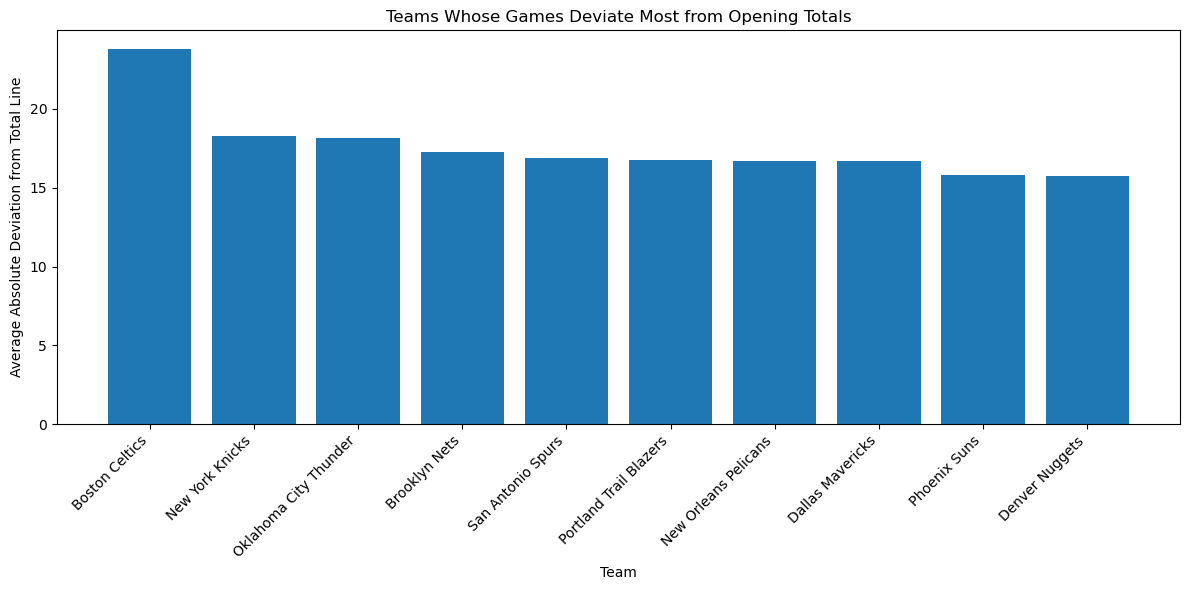

In [49]:
import matplotlib.pyplot as plt

top_teams = team_total_summary.sort_values(
    "avg_abs_total_diff", ascending=False
).head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_teams.index, top_teams["avg_abs_total_diff"])
plt.title("Teams Whose Games Deviate Most from Opening Totals")
plt.xlabel("Team")
plt.ylabel("Average Absolute Deviation from Total Line")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

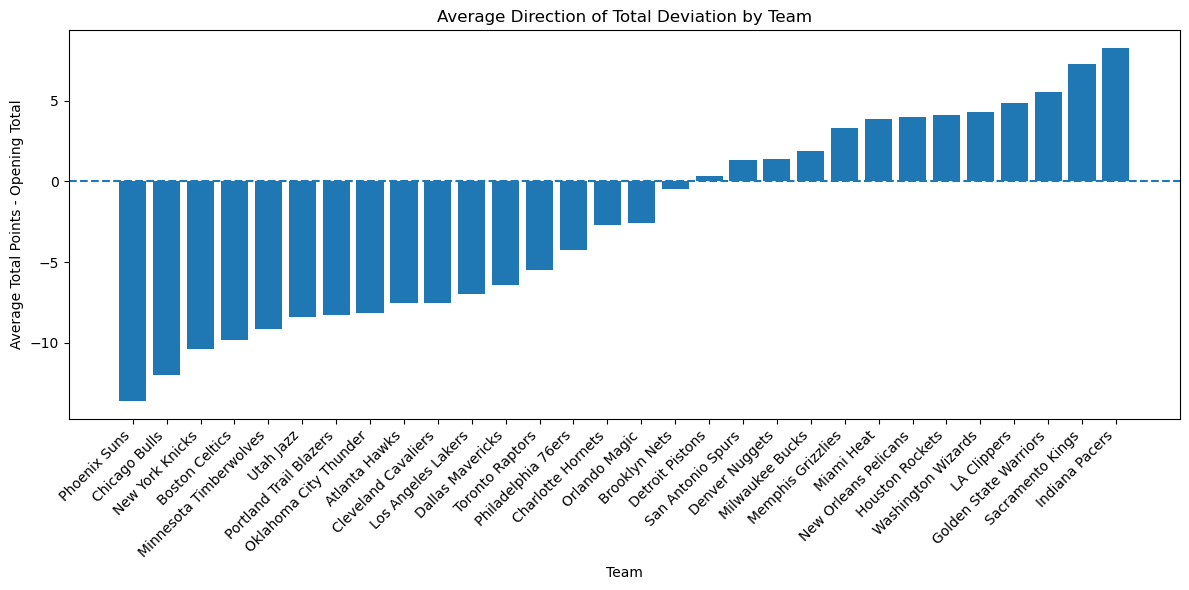

In [50]:
team_direction = team_totals.groupby("team")["total_diff_vs_line"].mean().sort_values()

plt.figure(figsize=(12, 6))
plt.bar(team_direction.index, team_direction.values)
plt.axhline(0, linestyle="--")
plt.title("Average Direction of Total Deviation by Team")
plt.xlabel("Team")
plt.ylabel("Average Total Points - Opening Total")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()